# Financial News Sentiment Classification
## Notebook 2: DistilBERT Fine-Tuning, Evaluation, and Error Analysis

**Project:** ADS-509 Final Project — Team 1  

This notebook covers:
1. DistilBERT setup — tokenization and HuggingFace Dataset conversion
2. Fine-tuning with `Trainer` (class weights, early stopping)
3. Model evaluation — confusion matrix, classification report, per-class F1
4. Figure generation — model comparison bar chart, per-class F1 chart
5. Error analysis — misclassified example review and pattern identification

**Prerequisites:** Run `01_EDA_preprocessing.ipynb` first to generate `data/train.csv`, `data/val.csv`, `data/test.csv`, and `data/vader_results.csv`.

## 1. Imports and Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
import evaluate

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
DATA_DIR    = '../data'
FIGURES_DIR = '../figures'
MODEL_DIR   = '../model_output'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Label mapping (must match Notebook 1)
LABEL_MAP   = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL    = {v: k for k, v in LABEL_MAP.items()}
LABEL_NAMES = ['negative', 'neutral', 'positive']

# Model — DistilBERT: 66M params, ~40% smaller and 60% faster than BERT-base
MODEL_CHECKPOINT = 'distilbert-base-uncased'

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Transformers / PyTorch ready.')

Using device: cuda
Transformers / PyTorch ready.


## 2. Load Data Splits

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# Ensure label column exists
for split_df, name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    if 'label' not in split_df.columns:
        split_df['label'] = split_df['sentiment'].map(LABEL_MAP)
    print(f'{name}: {len(split_df):,} rows | class dist: {split_df["sentiment"].value_counts().to_dict()}')

train: 3,386 rows | class dist: {'neutral': 2010, 'positive': 953, 'negative': 423}
val: 726 rows | class dist: {'neutral': 431, 'positive': 205, 'negative': 90}
test: 726 rows | class dist: {'neutral': 431, 'positive': 204, 'negative': 91}


## 3. Tokenization and Dataset Conversion

`distilbert-base-uncased` is a distilled version of BERT-base with 66M parameters — 40% smaller and 60% faster than BERT-base while retaining ~97% of its performance on downstream tasks (Sanh et al., 2019). We use its tokenizer to convert raw text into token IDs and attention masks, then wrap the splits as HuggingFace `Dataset` objects for the `Trainer` API.

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

MAX_LEN = 128  # Most financial sentences fit comfortably; BERT/DistilBERT max is 512

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding=False,         # Dynamic padding handled by DataCollatorWithPadding
        max_length=MAX_LEN,
    )

# Convert pandas DataFrames to HuggingFace Datasets
def make_hf_dataset(df):
    return Dataset.from_dict({'text': df['text'].tolist(), 'label': df['label'].tolist()})

raw_ds = DatasetDict({
    'train': make_hf_dataset(train_df),
    'val':   make_hf_dataset(val_df),
    'test':  make_hf_dataset(test_df),
})

tokenized_ds = raw_ds.map(tokenize, batched=True)
tokenized_ds = tokenized_ds.remove_columns(['text'])  # Keep only model inputs
tokenized_ds.set_format('torch')

print('Tokenized dataset:')
print(tokenized_ds)
print('\nSample features:', tokenized_ds['train'].features)

Map:   0%|          | 0/3386 [00:00<?, ? examples/s]

Map:   0%|          | 0/726 [00:00<?, ? examples/s]

Map:   0%|          | 0/726 [00:00<?, ? examples/s]

Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3386
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 726
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 726
    })
})

Sample features: {'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## 4. Model Setup — DistilBERT with Class Weights

In [4]:
# Class weights to address imbalance (Negative ~12.5%, most underrepresented)
class_counts = train_df['label'].value_counts().sort_index().values
total = class_counts.sum()
# Inverse-frequency weighting
class_weights = torch.tensor(
    total / (len(LABEL_MAP) * class_counts),
    dtype=torch.float
).to(DEVICE)

print('Class weights (negative / neutral / positive):')
for name, w in zip(LABEL_NAMES, class_weights.tolist()):
    print(f'  {name}: {w:.4f}')

Class weights (negative / neutral / positive):
  negative: 2.6682
  neutral: 0.5615
  positive: 1.1843


In [5]:
# Custom Trainer that applies class-weighted cross-entropy loss
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [6]:
# Load DistilBERT for 3-class sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(LABEL_MAP),
    id2label=ID2LABEL,
    label2id=LABEL_MAP,
)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model             : {MODEL_CHECKPOINT}')
print(f'Total parameters  : {total_params:,}')
print(f'Trainable params  : {trainable:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model             : distilbert-base-uncased
Total parameters  : 66,955,779
Trainable params  : 66,955,779


## 5. Fine-Tuning

In [7]:
# Compute metrics for evaluation during training
metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'macro_f1': macro_f1}

In [8]:
training_args = TrainingArguments(
    output_dir=MODEL_DIR,
    num_train_epochs=25,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    logging_steps=50,
    seed=SEED,
    report_to='none',           # Disable wandb/tensorboard logging
    fp16=(DEVICE == 'cuda'),    # Mixed precision only on CUDA
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [9]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['val'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)

In [10]:
print('Starting DistilBERT fine-tuning...')
train_result = trainer.train()
print('\nTraining complete.')
print(f'  Total steps  : {train_result.global_step}')
print(f'  Training loss: {train_result.training_loss:.4f}')

Starting DistilBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.993470,0.849080,0.703857,0.610181
2,0.466266,0.453095,0.775482,0.774059
3,0.323283,0.369970,0.838843,0.827802
4,0.257513,0.534491,0.842975,0.821932
5,0.113204,0.663348,0.844353,0.826754
6,0.093664,0.787843,0.853994,0.838590
7,0.019049,0.860300,0.852617,0.838220
8,0.049259,0.822726,0.852617,0.838093
9,0.016477,0.835963,0.841598,0.826142
10,0.010570,0.903312,0.844353,0.835642


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete.
  Total steps  : 2332
  Training loss: 0.2255


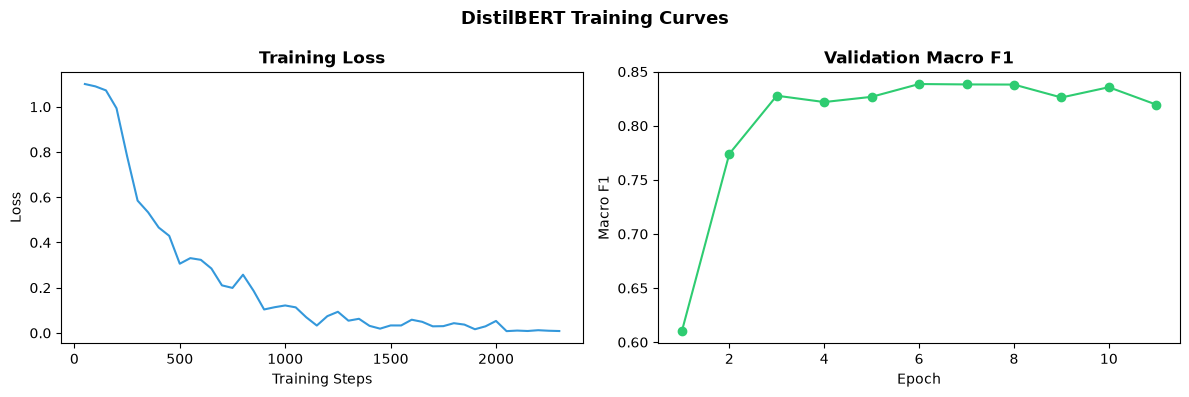

In [12]:
# Plot training loss curve
log_history = trainer.state.log_history
train_logs = [(e['step'], e['loss']) for e in log_history if 'loss' in e]
val_logs   = [(e['epoch'], e['eval_macro_f1']) for e in log_history if 'eval_macro_f1' in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if train_logs:
    steps, losses = zip(*train_logs)
    axes[0].plot(steps, losses, color='#3498db', linewidth=1.5)
    axes[0].set_xlabel('Training Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss', fontweight='bold')

if val_logs:
    epochs, f1s = zip(*val_logs)
    axes[1].plot(epochs, f1s, marker='o', color='#2ecc71', linewidth=1.5)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title('Validation Macro F1', fontweight='bold')

plt.suptitle('DistilBERT Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 6. Evaluation on Test Set

In [13]:
# Run inference on the held-out test set
pred_output = trainer.predict(tokenized_ds['test'])
y_pred_ids  = np.argmax(pred_output.predictions, axis=-1)
y_true_ids  = pred_output.label_ids

y_pred = [ID2LABEL[i] for i in y_pred_ids]
y_true = [ID2LABEL[i] for i in y_true_ids]

model_acc = accuracy_score(y_true, y_pred)
model_f1  = f1_score(y_true, y_pred, average='macro', labels=LABEL_NAMES)

print(f'DistilBERT Accuracy : {model_acc:.4f}')
print(f'DistilBERT Macro F1 : {model_f1:.4f}')
print()
print(classification_report(y_true, y_pred, labels=LABEL_NAMES))

DistilBERT Accuracy : 0.8499
DistilBERT Macro F1 : 0.8339

              precision    recall  f1-score   support

    negative       0.83      0.87      0.85        91
     neutral       0.86      0.91      0.89       431
    positive       0.83      0.71      0.77       204

    accuracy                           0.85       726
   macro avg       0.84      0.83      0.83       726
weighted avg       0.85      0.85      0.85       726



### 6.1 Confusion Matrix

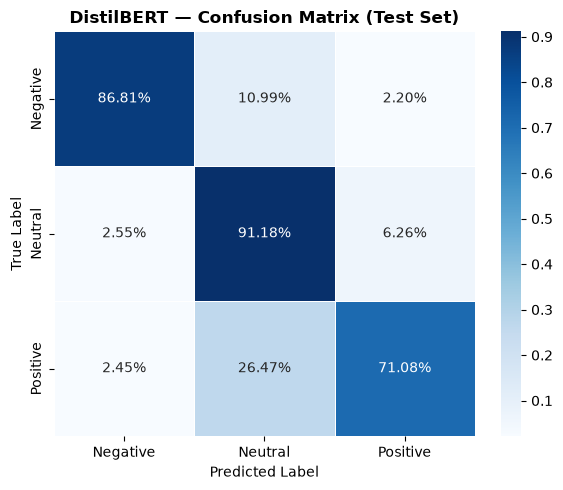

In [14]:
cm = confusion_matrix(y_true, y_pred, labels=LABEL_NAMES)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_pct, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=[l.capitalize() for l in LABEL_NAMES],
    yticklabels=[l.capitalize() for l in LABEL_NAMES],
    ax=ax, linewidths=0.5
)
ax.set_title('DistilBERT — Confusion Matrix (Test Set)', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'distilbert_confusion_matrix.png'), dpi=150)
plt.show()

## 7. Model Comparison Figures

### 7.1 Overall Accuracy and Macro F1 Comparison

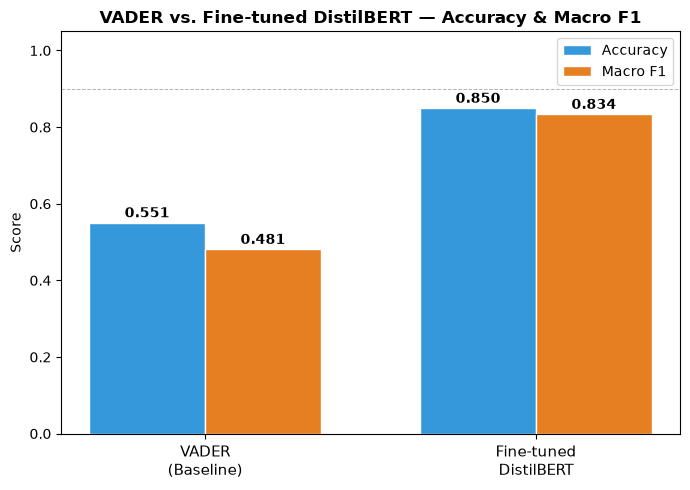

In [15]:
# Load VADER results saved in Notebook 1
vader_results = pd.read_csv(os.path.join(DATA_DIR, 'vader_results.csv')).iloc[0]

models   = ['VADER\n(Baseline)', 'Fine-tuned\nDistilBERT']
acc_vals = [vader_results['accuracy'], model_acc]
f1_vals  = [vader_results['macro_f1'], model_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy',  color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, f1_vals,  width, label='Macro F1', color='#e67e22', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('VADER vs. Fine-tuned DistilBERT — Accuracy & Macro F1',
             fontweight='bold', fontsize=12)
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_comparison_bar.png'), dpi=150)
plt.show()

### 7.2 Per-Class F1 Comparison

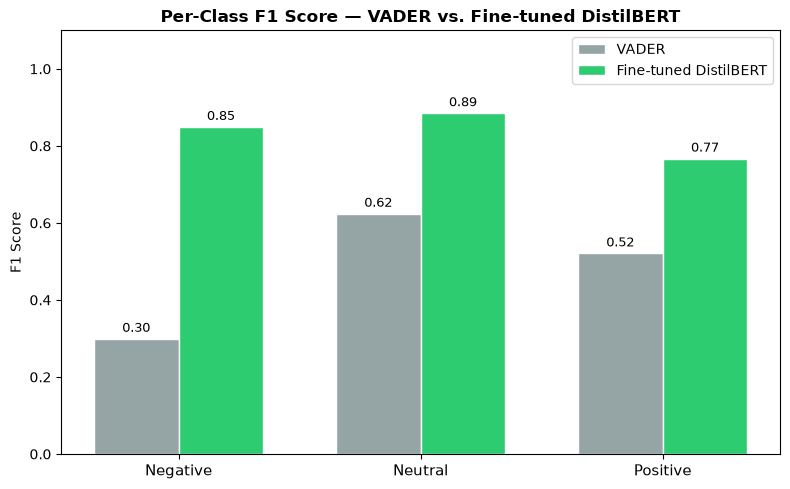

In [16]:
# Reload test set with VADER predictions for per-class comparison
test_df_with_vader = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))

# If vader_pred column exists use it; otherwise recompute
if 'vader_pred' not in test_df_with_vader.columns:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    _va = SentimentIntensityAnalyzer()
    def _vader(text):
        c = _va.polarity_scores(text)['compound']
        return 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
    test_df_with_vader['vader_pred'] = test_df_with_vader['text'].apply(_vader)

from sklearn.metrics import f1_score as sk_f1

vader_per_class = sk_f1(
    test_df_with_vader['sentiment'], test_df_with_vader['vader_pred'],
    average=None, labels=LABEL_NAMES
)
model_per_class = sk_f1(y_true, y_pred, average=None, labels=LABEL_NAMES)

x = np.arange(len(LABEL_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, vader_per_class,  width, label='VADER',               color='#95a5a6', edgecolor='white')
ax.bar(x + width/2, model_per_class,  width, label='Fine-tuned DistilBERT', color='#2ecc71', edgecolor='white')

for i, (v, f) in enumerate(zip(vader_per_class, model_per_class)):
    ax.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, f + 0.01, f'{f:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in LABEL_NAMES], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score — VADER vs. Fine-tuned DistilBERT',
             fontweight='bold', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'per_class_f1.png'), dpi=150)
plt.show()

## 8. Error Analysis

We examine sentences where DistilBERT was wrong to understand systematic failure modes.

In [17]:
error_df = test_df.copy()
error_df['model_pred']  = y_pred
error_df['true_label']  = y_true
error_df['correct']     = error_df['true_label'] == error_df['model_pred']

misclassified = error_df[~error_df['correct']].copy()
print(f'Misclassified: {len(misclassified):,} / {len(error_df):,} ({len(misclassified)/len(error_df):.1%})')
print('\nError counts by (true → predicted):')
misclassified.groupby(['true_label', 'model_pred']).size().sort_values(ascending=False)

Misclassified: 109 / 726 (15.0%)

Error counts by (true → predicted):


true_label  model_pred
positive    neutral       54
neutral     positive      27
            negative      11
negative    neutral       10
positive    negative       5
negative    positive       2
dtype: int64

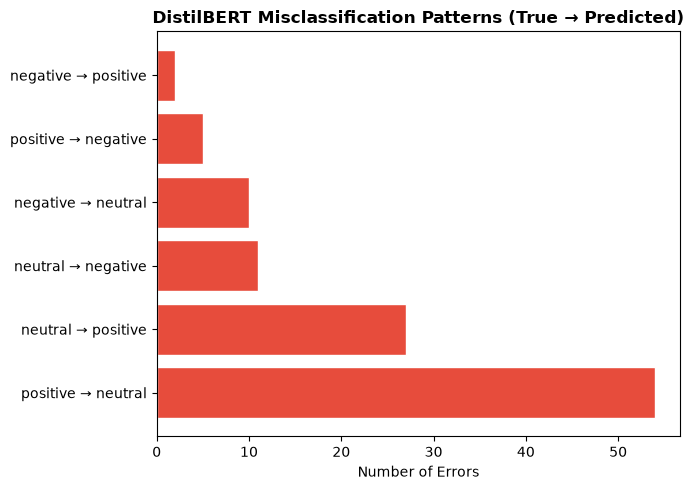

In [18]:
# Error type distribution bar chart
error_counts = misclassified.groupby(['true_label', 'model_pred']).size().reset_index(name='count')
error_counts['label'] = error_counts['true_label'] + ' → ' + error_counts['model_pred']
error_counts = error_counts.sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(error_counts['label'], error_counts['count'], color='#e74c3c', edgecolor='white')
ax.set_xlabel('Number of Errors')
ax.set_title('DistilBERT Misclassification Patterns (True → Predicted)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'error_types.png'), dpi=150)
plt.show()

In [19]:
# Show representative misclassified examples for the most common error types
print('=' * 80)
print('SAMPLE MISCLASSIFIED EXAMPLES (up to 5 per error type)')
print('=' * 80)

top_errors = error_counts.head(4)
for _, row in top_errors.iterrows():
    true_l, pred_l = row['true_label'], row['model_pred']
    subset = misclassified[
        (misclassified['true_label'] == true_l) &
        (misclassified['model_pred'] == pred_l)
    ]['text'].head(5)
    print(f'\n--- True: {true_l.upper()}  →  Predicted: {pred_l.upper()} ({row["count"]} cases) ---')
    for i, text in enumerate(subset, 1):
        print(f'  {i}. {text}')

SAMPLE MISCLASSIFIED EXAMPLES (up to 5 per error type)

--- True: POSITIVE  →  Predicted: NEUTRAL (54 cases) ---
  1. Finnish mobile operator DNA will function as a subcontractor to Maingate and will be responsible for telecommunications connections .
  2. YIT says the acquisition is a part of its strategy for expansion in Central and Eastern European markets .
  3. Viking Line head Jan Kaarstroem told TT that his company 's ferries were well equipped to handle ice and that all the passengers were safe .
  4. Tieto was looking for an energy solution which would best support the idea of sustainable development , and we were happy to be able to provide such a solution , saysJouni Haikarainen , Vice President , Fortum .
  5. Furthermore , our fully electrically driven cranes are environmentally friendly .

--- True: NEUTRAL  →  Predicted: POSITIVE (27 cases) ---
  1. The desk will reach its full planned strength of ten persons in autumn 2007 .
  2. The goal is to secure the company 's pro

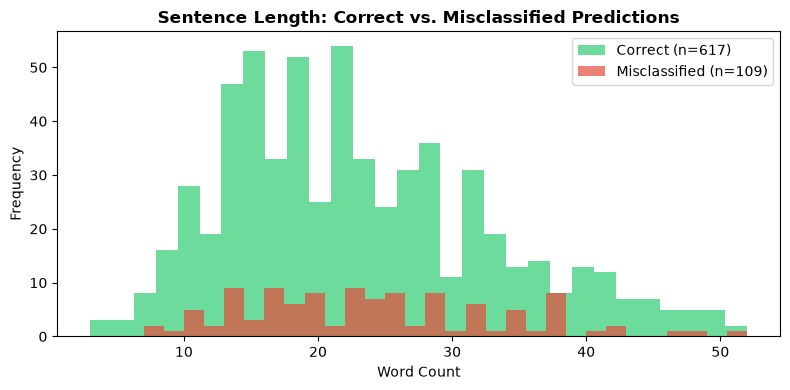

Mean word count — correct   : 23.1
Mean word count — wrong     : 24.0


In [20]:
# Error analysis: sentence length distribution for correct vs. incorrect predictions
error_df['word_count'] = error_df['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, alpha in [('Correct', '#2ecc71', 0.7), ('Misclassified', '#e74c3c', 0.7)]:
    is_correct = label == 'Correct'
    subset = error_df[error_df['correct'] == is_correct]['word_count']
    ax.hist(subset, bins=30, alpha=alpha, color=color, label=f'{label} (n={len(subset):,})', edgecolor='none')

ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Sentence Length: Correct vs. Misclassified Predictions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'error_length_dist.png'), dpi=150)
plt.show()

print('Mean word count — correct   :', error_df[error_df['correct']]['word_count'].mean().round(1))
print('Mean word count — wrong     :', error_df[~error_df['correct']]['word_count'].mean().round(1))

### Error Analysis Summary

The fine-tuned DistilBERT model misclassified **109 of 726 test examples (15.0%)**, stopping at approximately **epoch 11** (2,332 steps) of the 25-epoch max due to early stopping (patience=5), indicating the model plateaued around epoch 6.

**Key patterns in misclassifications:**

1. **Positive → Neutral is the dominant error (54 cases, 49.5% of all errors)**: Positive financial news expressed in factual or procedural language — acquisitions, strategic expansions, safety confirmations — lacks overtly positive sentiment words, causing the model to default to Neutral. This is the root cause behind Positive's low recall (0.71) and its weakest per-class F1 (0.77).

2. **Neutral → Positive (27 cases)**: Goal-oriented and forward-looking neutral statements ("goal is to secure profitability", "will reach full planned strength") are falsely read as positive. These sentences describe intentions rather than outcomes but contain progress-framing language.

3. **Neutral → Negative (11 cases)**: Neutral reports containing negative-sounding financial figures (operating losses, price cuts, stock drops) are misread as Negative, even when the surrounding context is factual and non-evaluative.

4. **Negative class is well-handled despite imbalance**: Inverse-frequency class weighting (2.67× for Negative) was effective — Negative achieved the highest recall (0.87) and F1 (0.85) despite being the most underrepresented class (~12.5% of training data). Only 12 negative examples were misclassified in total.

5. **Sentence length is a weak signal**: Misclassified sentences averaged 24.0 words vs. 23.1 for correct predictions — a negligible difference suggesting length is not a meaningful error driver here.

## 9. Final Results Summary

In [21]:
summary = pd.DataFrame([
    {'Model': 'VADER (Baseline)',       'Accuracy': vader_results['accuracy'], 'Macro F1': vader_results['macro_f1']},
    {'Model': 'Fine-tuned DistilBERT', 'Accuracy': round(model_acc, 4),       'Macro F1': round(model_f1, 4)},
])

acc_gain = model_acc - vader_results['accuracy']
f1_gain  = model_f1  - vader_results['macro_f1']

print('=' * 50)
print('FINAL RESULTS — TEST SET')
print('=' * 50)
print(summary.to_string(index=False))
print(f'\nAccuracy improvement : +{acc_gain:.4f} ({acc_gain*100:.2f} pp)')
print(f'Macro F1 improvement : +{f1_gain:.4f}  ({f1_gain*100:.2f} pp)')

summary.to_csv(os.path.join(DATA_DIR, 'final_results.csv'), index=False)
print('\nResults saved to data/final_results.csv')

FINAL RESULTS — TEST SET
                Model  Accuracy  Macro F1
     VADER (Baseline)    0.5510    0.4815
Fine-tuned DistilBERT    0.8499    0.8339

Accuracy improvement : +0.2989 (29.89 pp)
Macro F1 improvement : +0.3524  (35.24 pp)

Results saved to data/final_results.csv


## 10. Save Fine-tuned Model

In [22]:
trainer.save_model(os.path.join(MODEL_DIR, 'distilbert_finetuned'))
tokenizer.save_pretrained(os.path.join(MODEL_DIR, 'distilbert_finetuned'))
print(f'Model saved to {MODEL_DIR}/distilbert_finetuned/')
print('\nAll figures saved to figures/')
print('Notebook 2 complete.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ../model_output/distilbert_finetuned/

All figures saved to figures/
Notebook 2 complete.
